<a href="https://colab.research.google.com/github/Ximenaloranca/Procesos-Estocasticos/blob/main/Descomposicioncanonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descomposición canónica

La descomposición canónica de una matriz de transición $P$ consiste en aplicar una permutación a sus filas y columnas para agrupar los estados según esta partición. Adoptando la convención analítica de posicionar primero los estados transitorios y posteriormente los recurrentes, la matriz reorganizada adopta la siguiente estructura de bloques algebraicos:

$$
P_{can} = \begin{pmatrix} Q & R \\ 0 & P_{rec} \end{pmatrix}
$$

Donde cada submatriz tiene una interpretación probabilística específica

Ejercicio 1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.

En esta primera parte definimos la matriz y realizamos su diagrama de transiciones, respecto a la siguiente matriz

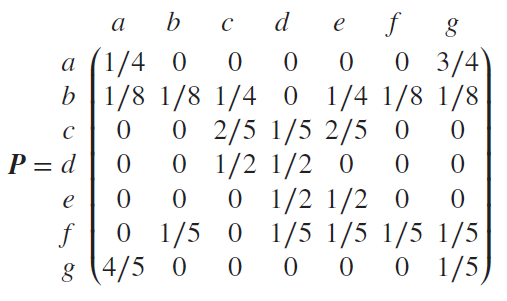

In [38]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Definimos los estados y la matriz de transición P
estados = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

P = np.array([
    [1/4,   0,   0,   0,   0,   0, 3/4],
    [1/8, 1/8, 1/4,   0, 1/4, 1/8, 1/8],
    [  0,   0, 2/5, 1/5, 2/5,   0,   0],
    [  0,   0, 1/2, 1/2,   0,   0,   0],
    [  0,   0,   0, 1/2, 1/2,   0,   0],
    [  0, 1/5,   0, 1/5, 1/5, 1/5, 1/5],
    [4/5,   0,   0,   0,   0,   0, 1/5]
])

# Imprimimos la matriz P
print(" Matriz P ")
np.set_printoptions(precision=3, suppress=True) # Esto es para los decimales
print(P)
print("\n")



 Matriz P 
[[0.25  0.    0.    0.    0.    0.    0.75 ]
 [0.125 0.125 0.25  0.    0.25  0.125 0.125]
 [0.    0.    0.4   0.2   0.4   0.    0.   ]
 [0.    0.    0.5   0.5   0.    0.    0.   ]
 [0.    0.    0.    0.5   0.5   0.    0.   ]
 [0.    0.2   0.    0.2   0.2   0.2   0.2  ]
 [0.8   0.    0.    0.    0.    0.    0.2  ]]




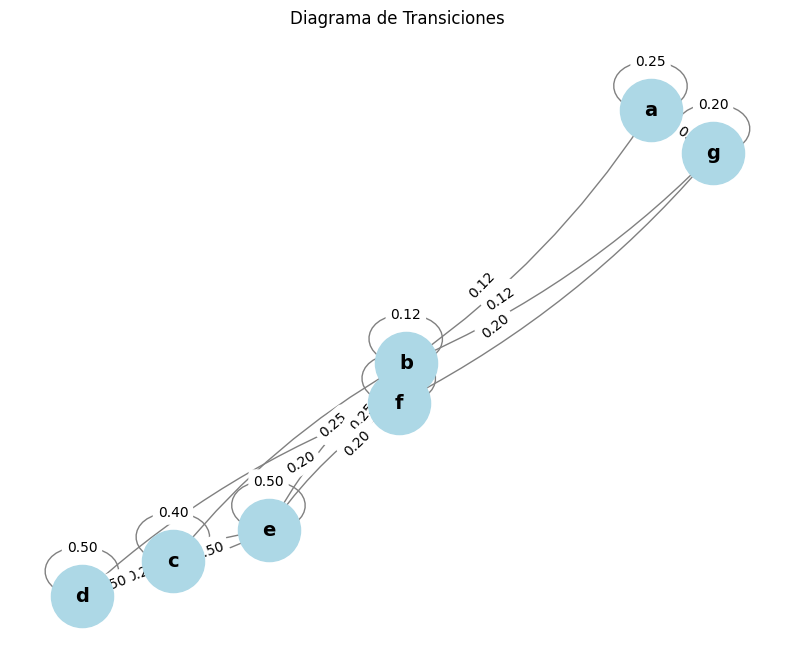

In [39]:
# Dibujamos el diagrama de transiciones
def dibujar_diagrama(P, estados):
    G = nx.DiGraph()
    n = len(estados)

    # Agregar aristas con pesos mayores a 0
    for i in range(n):
        for j in range(n):
            if P[i, j] > 0:
                G.add_edge(estados[i], estados[j], weight=P[i, j])

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=42) # Layout para mejor visualización

    # Dibujar nodos y aristas
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2000)
    nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

    # Dibujar aristas con curvatura para las de ida y vuelta
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowstyle='-|>', arrowsize=20, connectionstyle="arc3,rad=0.1")

    # Etiquetas de los pesos (probabilidades)
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10, label_pos=0.3)

    plt.title("Diagrama de transiciones")
    plt.axis('off')
    plt.show()

dibujar_diagrama(P, estados)


Ejercicio 2. Determine si la matriz tiene o no distribución límite.

Para que una matriz tenga una distribucion limite debe de ser aperiodica e irreducible, en el siguiente codigo aplicamos esto para saber si esta matriz tiene o no la distribucion limite

In [40]:
# Reconstruimos el grafo G usando la matriz P para la comprobacion
G_comprobacion = nx.DiGraph()
for i in range(len(estados)):
    for j in range(len(estados)):
        if P[i, j] > 0:
            G_comprobacion.add_edge(estados[i], estados[j])

# Comprobamos que es irreducible
es_irreducible = nx.is_strongly_connected(G_comprobacion)

print(" Distribución límite ")
print(f"¿La cadena de Markov es irreducible?: {es_irreducible}")

if not es_irreducible:
    print("\nConclusión: Como la cadena no es irreducible, no tiene una distribución límite única.")

    # Extraemos los componentes para demostrar las clases
    componentes = list(nx.strongly_connected_components(G_comprobacion))
    print(f"\nClases de comunicación son {len(componentes)} en total:")
    for idx, comp in enumerate(componentes):
        print(f"Clase {idx + 1}: {list(comp)}")


 Distribución límite 
¿La cadena de Markov es irreducible?: False

Conclusión: Como la cadena no es irreducible, no tiene una distribución límite única.

Clases de comunicación son 3 en total:
Clase 1: ['a', 'g']
Clase 2: ['c', 'e', 'd']
Clase 3: ['b', 'f']


Ejercicio 3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.

En esta parte unicamente hacemos la forma canonica de la matriz y para calcular el limite la vamos a elevar a una potencia muy grande

In [41]:
# Para la forma canonica
orden = [1, 5, 0, 6, 2, 3, 4] # Vamos de b, f, a, g, c, d, e
estados_can = [estados[i] for i in orden]

# Creamos la matriz canonica
P_can = P[np.ix_(orden, orden)]

print("Matriz canonica")
print(f"Orden de estados: {estados_can}")
np.set_printoptions(precision=4, suppress=True)
print(P_can)

# Calculamos el límite de Pn elevando la matriz a una potencia grande
n = 1000
P_lim = np.linalg.matrix_power(P_can, n)

print(" Límite de la matriz ")
print(P_lim)

# Extraemos y calculamos las distribuciones límite de las submatrices
P1 = P_can[2:4, 2:4]
A1 = np.vstack(((P1 - np.eye(2)).T, np.ones(2)))
b1 = np.array([0, 0, 1])
pi_1 = np.linalg.lstsq(A1, b1, rcond=None)[0]

# R2 está en los índices 4, 5 y 6 de la  matriz
P2 = P_can[4:7, 4:7]
A2 = np.vstack(((P2 - np.eye(3)).T, np.ones(3)))
b2 = np.array([0, 0, 0, 1])
pi_2 = np.linalg.lstsq(A2, b2, rcond=None)[0]

print("Distribuciones limite de las submatrices")
print(f"Distribucion limite de R1 (a, g): {pi_1}")
print(f"Distribucion limite de R2 (c, d, e): {pi_2}")


Matriz canonica
Orden de estados: ['b', 'f', 'a', 'g', 'c', 'd', 'e']
[[0.125 0.125 0.125 0.125 0.25  0.    0.25 ]
 [0.2   0.2   0.    0.2   0.    0.2   0.2  ]
 [0.    0.    0.25  0.75  0.    0.    0.   ]
 [0.    0.    0.8   0.2   0.    0.    0.   ]
 [0.    0.    0.    0.    0.4   0.2   0.4  ]
 [0.    0.    0.    0.    0.5   0.5   0.   ]
 [0.    0.    0.    0.    0.    0.5   0.5  ]]
 Límite de la matriz 
[[0.     0.     0.172  0.1613 0.2222 0.2667 0.1778]
 [0.     0.     0.172  0.1613 0.2222 0.2667 0.1778]
 [0.     0.     0.5161 0.4839 0.     0.     0.    ]
 [0.     0.     0.5161 0.4839 0.     0.     0.    ]
 [0.     0.     0.     0.     0.3333 0.4    0.2667]
 [0.     0.     0.     0.     0.3333 0.4    0.2667]
 [0.     0.     0.     0.     0.3333 0.4    0.2667]]
Distribuciones limite de las submatrices
Distribucion limite de R1 (a, g): [0.5161 0.4839]
Distribucion limite de R2 (c, d, e): [0.3333 0.4    0.2667]


Comparacion: ​Al analizar el límite de la matriz y compararlo con las distribuciones límite de las submatrices, observamos un patron. Para la clase R1 (a, g), sus filas en la matriz límite convergen a los valores de su distribución estacionaria local pi1.

Para la clase R2 (c, d, e), sus filas convergen de manera a su respectiva distribución.

En los estados transitorios (b, f), sus filas muestran cómo se reparte la probabilidad de ser absorbidos por R1 o R2, multiplicada por la distribución límite de la clase de destino.

**Conclusión**

La descomposición canónica demuestra que el sistema no tiene una distribución límite. El comportamiento a largo plazo de la cadena depende de la clase recurrente que la absorba, y cuando se queda atrapada en, la cadena evoluciona de manera independiente alcanzando el equilibrio dictado por las pi, respectivamente.